In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [ ]:
# import standard python libraries
import os, urllib, io
from datetime import datetime
import numpy as np

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay, cKDTree
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.ndimage import maximum_filter, minimum_filter
from matplotlib.colors import LogNorm
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial import Delaunay
import matplotlib.tri as mtri
from array import array
from collections import defaultdict
from matplotlib.patches import Rectangle

In [ ]:
import pandas as pd
from pathlib import Path

In [ ]:
# import the Google Colab GDrive connector
from google.colab import drive

# mount GDrive inside the Colab notebook
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# create Colab Notebooks directory
notebook_directory = '/content/drive/MyDrive/Colab Notebooks'
if not os.path.exists(notebook_directory): os.makedirs(notebook_directory)

 # create data sub-directory inside the Colab Notebooks directory
data_directory = '/content/drive/MyDrive/Colab-Notebooks/Autoencoder/tensor'
if not os.path.exists(data_directory): os.makedirs(data_directory)

 # create models sub-directory inside the Colab Notebooks directory
models_directory = '/content/drive/MyDrive/Colab-Notebooks/Autoencoder/models'
if not os.path.exists(models_directory): os.makedirs(models_directory)

In [ ]:
# init deterministic seed
seed_value = 1234
np.random.seed(seed_value) # set numpy seed
torch.manual_seed(seed_value) # set pytorch seed CPU

In [ ]:
input_tensor = torch.load(f"{data_directory}/tensors_autoencoder.pt")
output_tensor = torch.load(f"{data_directory}/tensors_autoencoder.pt")

In [ ]:
print(len(input_tensor))
print(output_tensor[0].shape)
print(input_tensor[0].shape)

1000
torch.Size([3, 128, 128])
torch.Size([3, 128, 128])


In [ ]:
class DoubleConv(nn.Module):
    """
    Two consecutive Conv → BatchNorm → ReLU sequences.
    This is the basic building block used in every encoder
    and decoder stage of the U-Net.

    in_channels  : number of feature maps coming in
    out_channels : number of feature maps going out
    """


    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.block = nn.Sequential(
            # First convolution: slides a 3×3 kernel over the input.
            # padding=1 keeps the spatial size (H, W) unchanged.
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),

            # BatchNorm normalises each channel over the batch so that activations stay in a healthy numerical range.
            #This stabilises and accelerates training. bias=False above is intentional: BatchNorm has its own learnable bias (beta).
            nn.BatchNorm2d(out_channels),

            # ReLU introduces non-linearity, letting the network learn complex mappings. inplace=True modifies the tensor in memory,
            #saving a small amount of RAM.
            nn.ReLU(inplace=True),

            # Second convolution, same idea as above.
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Simply pass x through all layers defined in self.block.
        return self.block(x)

# ─────────────────────────────────────────────────────────────
# Autoencoder
# ─────────────────────────────────────────────────────────────

class Autoencoder(nn.Module):
    """
    Full U-Net.

    Encoder path  : 4 stages, each doubles the channel count and
                    halves spatial resolution via MaxPool.
    Bottleneck    : deepest representation (no pooling).
    Decoder path  : 4 stages, each halves the channel count and
                    doubles spatial resolution via ConvTranspose2d.
    Skip connections: feature maps from each encoder stage are
                    concatenated to the corresponding decoder stage,
                    giving the decoder access to fine spatial detail
                    that would otherwise be lost during downsampling.

    in_channels   : channels of the input tensor  (3 for RGB)
    out_channels  : channels of the output tensor (2 for your task)
    features      : base channel width; doubles at each encoder stage
    """

    def __init__(self, in_channels: int = 3, out_channels: int = 3,
                 features: int = 64):
        super().__init__()


In [ ]:

# ─────────────────────────────────────────────────────────────
# Autoencoder
# ─────────────────────────────────────────────────────────────

class Autoencoder(nn.Module):
    """
    Full U-Net.

    Encoder path  : 4 stages, each doubles the channel count and
                    halves spatial resolution via MaxPool.
    Bottleneck    : deepest representation (no pooling).
    Decoder path  : 4 stages, each halves the channel count and
                    doubles spatial resolution via ConvTranspose2d.
    Skip connections: feature maps from each encoder stage are
                    concatenated to the corresponding decoder stage,
                    giving the decoder access to fine spatial detail
                    that would otherwise be lost during downsampling.

    in_channels   : channels of the input tensor  (3 for RGB)
    out_channels  : channels of the output tensor (2 for your task)
    features      : base channel width; doubles at each encoder stage
    """

    def __init__(self, in_channels: int = 3, out_channels: int = 3,
                 features: int = 64):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────
        # Each DoubleConv extracts richer features at a coarser scale.
        # Stored in a ModuleList so PyTorch registers them as parameters.

        self.enc1 = DoubleConv(in_channels, features)         # 4  → 64  ch
        self.enc2 = DoubleConv(features,     features * 2)    # 64 → 128 ch
        self.enc3 = DoubleConv(features * 2, features * 4)    # 12**++8→ 256 ch
        self.enc4 = DoubleConv(features * 4, features * 8)    # 256→ 512 ch

        # MaxPool halves each spatial dimension (128→64→32→16→8).
        # kernel_size=2, stride=2 means every non-overlapping 2×2
        # region collapses to one value (the maximum).
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Bottleneck ────────────────────────────────────────
        # Deepest layer: 8×8 spatial size, 1024 channels.
        # No pooling here — we immediately start going back up.
        self.bottleneck = DoubleConv(features * 8, features * 16)  # 512→1024 ch

        # ── Decoder ──────────────────────────────────────────
        # ConvTranspose2d is the "learnable upsampling" step.
        # kernel_size=2, stride=2 doubles H and W (inverse of MaxPool).
        # After upsampling, the skip connection is concatenated, so the
        # next DoubleConv sees (upsampled_channels + skip_channels).

        # Stage 4: upsample 1024→512, then concat skip4 (512) → input 1024
        #ConvTranspose2d is like the inverse of MaxPool.
        self.up4   = nn.ConvTranspose2d(features * 16, features * 8,
                                        kernel_size=2, stride=2)
        self.dec4  = DoubleConv(features * 16, features * 8)   # 1024→512 ch

        # Stage 3: upsample 512→256, concat skip3 (256) → input 512
        self.up3   = nn.ConvTranspose2d(features * 8, features * 4,
                                        kernel_size=2, stride=2)
        self.dec3  = DoubleConv(features * 8, features * 4)    # 512→256 ch

        # Stage 2: upsample 256→128, concat skip2 (128) → input 256
        self.up2   = nn.ConvTranspose2d(features * 4, features * 2,
                                        kernel_size=2, stride=2)
        self.dec2  = DoubleConv(features * 4, features * 2)    # 256→128 ch

        # Stage 1: upsample 128→64, concat skip1 (64) → input 128
        self.up1   = nn.ConvTranspose2d(features * 2, features,
                                        kernel_size=2, stride=2)
        self.dec1  = DoubleConv(features * 2, features)        # 128→64 ch

        # ── Output head ──────────────────────────────────────
        # A 1×1(kernel) convolution maps 64 channels → out_channels (2).
        # No activation here — apply softmax/sigmoid outside if needed.
        self.output_conv = nn.Conv2d(features, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ── Encoder forward ──────────────────────────────────
        # Each skip_N tensor is saved to be concatenated later.

        skip1 = self.enc1(x)            # (B,  64, 128, 128)
        skip2 = self.enc2(self.pool(skip1))   # (B, 128,  64,  64)
        skip3 = self.enc3(self.pool(skip2))   # (B, 256,  32,  32)
        skip4 = self.enc4(self.pool(skip3))   # (B, 512,  16,  16)


        # ── Bottleneck ────────────────────────────────────────
        x = self.bottleneck(self.pool(skip4))  # (B, 1024, 8, 8)

        # ── Decoder forward ──────────────────────────────────
        # torch.cat concatenates along the channel dimension (dim=1).
        # This is the "U" in U-Net: the skip gives the decoder exact
        # spatial information from the corresponding encoder stage.

        x = self.up4(x)                        # (B, 512, 16, 16)
        x = torch.cat([x, skip4], dim=1)       # (B, 1024, 16, 16) #I dont understand the cocatenation
        x = self.dec4(x)                       # (B, 512, 16, 16)

        x = self.up3(x)                        # (B, 256, 32, 32)
        x = torch.cat([x, skip3], dim=1)       # (B, 512, 32, 32)
        x = self.dec3(x)                       # (B, 256, 32, 32)

        x = self.up2(x)                        # (B, 128, 64, 64)
        x = torch.cat([x, skip2], dim=1)       # (B, 256, 64, 64)
        x = self.dec2(x)                       # (B, 128, 64, 64)

        x = self.up1(x)                        # (B, 64, 128, 128)
        x = torch.cat([x, skip1], dim=1)       # (B, 128, 128, 128)
        x = self.dec1(x)                       # (B, 64, 128, 128)

        # ── Output ───────────────────────────────────────────
        return self.output_conv(x)             # (B, 2, 128, 128)

In [ ]:
# ─────────────────────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────────────────────

class TensorDataset(Dataset):
    """
    Wraps pre-loaded input and target tensors into a PyTorch Dataset.

    inputs  : FloatTensor of shape (N, 3, 128, 128)
    targets : FloatTensor of shape (N, 2, 128, 128)
    """

    def __init__(self, inputs: torch.Tensor, targets: torch.Tensor):
        # Basic sanity check: number of samples must match.
        assert inputs.shape[0] == targets.shape[0], \
            "inputs and targets must have the same number of samples"
        self.inputs  = inputs
        self.targets = targets

    def __len__(self) -> int:
        # DataLoader calls this to know the total number of samples.
        return self.inputs.shape[0]

    def __getitem__(self, idx: int):
        # Returns a single (input, target) pair by index.
        # DataLoader will stack these into batches automatically.
        return self.inputs[idx], self.targets[idx]


In [ ]:
# Calculate the split index for 80% training and 20% validation
# Convert input_tensor and output_tensor from lists of tensors to single stacked tensors
stacked_input_tensor = torch.stack(input_tensor, dim=0)
print(stacked_input_tensor.shape)# Shape: [;,3,128,128]
stacked_output_tensor = torch.stack(output_tensor, dim=0)
print(stacked_input_tensor.shape)# Shape: [;,3,128,128]

total_samples = len(stacked_input_tensor) # Use the length of the stacked tensor
train_size = int(0.8 * total_samples)

# Split the stacked tensors
# torch.randperm returns a random permutation of indices, which
# ensures the split is randomised (not just the last N samples).
perm = torch.randperm(total_samples)

# Now, index the stacked tensors using the permutation directly
Input = stacked_input_tensor[perm[:train_size]]
Output = stacked_output_tensor[perm[:train_size]]
Input_val = stacked_input_tensor[perm[train_size:]]
Output_val = stacked_output_tensor[perm[train_size:]]


# Print the shape of the combined tensors to verify
print(f"Input (training) shape: {Input.shape}")
print(f"Output (training) shape: {Output.shape}")
print(f"Input (validation) shape: {Input_val.shape}")
print(f"Output (validation) shape: {Output_val.shape}")

torch.Size([1000, 3, 128, 128])
torch.Size([1000, 3, 128, 128])
Input (training) shape: torch.Size([800, 3, 128, 128])
Output (training) shape: torch.Size([800, 3, 128, 128])
Input (validation) shape: torch.Size([200, 3, 128, 128])
Output (validation) shape: torch.Size([200, 3, 128, 128])


In [ ]:
# ── DataLoaders ──────────────────────────────────────────
# DataLoader handles batching, shuffling, and (optionally)
# multi-process data loading (num_workers > 0).
batch_size = 8
train_loader = DataLoader(
    TensorDataset(Input, Output),
    batch_size=batch_size,
    shuffle=True,    # shuffle every epoch to reduce overfitting
)
val_loader = DataLoader(
    TensorDataset(Input_val, Output_val),
    batch_size=batch_size,
    shuffle=False,   # no need to shuffle validation data
)

In [ ]:
%%time

# ─────────────────────────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────────────────────────

total_samples = len(stacked_input_tensor) # Use the length of the stacked tensor
train_size = int(0.8 * total_samples)
val_size = total_samples - train_size

def train(
#    inputs:       torch.Tensor,
#    targets:      torch.Tensor,
    num_epochs:   int   = 100,
    batch_size:   int   = 8,
    learning_rate:float = 1e-4,
    val_split:    float = 0.2,
):
    """
    Full training pipeline.

    inputs        : (N, 3, 128, 128) input tensors
    targets       : (N, 2, 128, 128) target tensors
    num_epochs    : how many full passes over the training set
    batch_size    : how many samples per gradient update
    learning_rate : step size for the Adam optimiser
    val_split     : fraction of data held out for validation
    """

    # ── Device setup ─────────────────────────────────────────
    # Automatically use a GPU if one is available; otherwise CPU.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")


    # ── Model, loss, optimiser ────────────────────────────────
    model = Autoencoder(in_channels=3, out_channels=3).to(device)

    # MSELoss computes the mean squared error between prediction and target.
    #For segmentation tasks you might swap this for CrossEntropyLoss
    #(with integer class maps) or BCEWithLogitsLoss.
    criterion = nn.MSELoss()

    # Adam is an adaptive gradient optimiser that works well out of the
    # box for most deep learning tasks.
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_losses = []
    val_losses = []

    # ── Training loop ─────────────────────────────────────────
    for epoch in range(1, num_epochs + 1):

        # ── Training phase ────────────────────────────────────
        model.train()   # enables dropout / BatchNorm training behaviour
        train_loss = 0.0

        for batch_inputs, batch_targets in train_loader:
            # Move data to the same device as the model.
            batch_inputs  = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)

            # Zero out gradients from the previous step. If you forget
            # this, gradients accumulate and your updates are wrong.
            optimizer.zero_grad()

            # Forward pass: compute the model's predictions.
            predictions = model(batch_inputs)

            # Compute the scalar loss between predictions and targets.
            loss = criterion(predictions, batch_targets)

            # Backward pass: compute gradients of the loss w.r.t. every
            # parameter via automatic differentiation (backprop).
            loss.backward()

            # Update parameters by taking one gradient descent step.
            optimizer.step()

            # Accumulate the loss (detach so no gradient history is kept).
            train_loss += loss.item() * batch_inputs.size(0)

        train_loss /= train_size  # average over samples
        train_losses.append(train_loss)



        # ── Validation phase ──────────────────────────────────


        model.eval()    # disables dropout / uses running stats for BN
        val_loss = 0.0

        with torch.no_grad():  # disable gradient computation to save memory
            for batch_inputs, batch_targets in val_loader:
                batch_inputs  = batch_inputs.to(device)
                batch_targets = batch_targets.to(device)

                predictions = model(batch_inputs)
                loss = criterion(predictions, batch_targets) # Validation loss
                # Loss between the predictions and the output (targets).
                val_loss += loss.item() * batch_inputs.size(0)

        val_loss /= val_size  # average over samples
        val_losses.append(val_loss)

        # Print progress every 10 epochs (and always at the last epoch).
        print(f"Epoch {epoch:3d}: "
              f"Train Loss = {train_loss:.4f}, "
              f"Val Loss = {val_loss:.4f}")

    print("Training complete.")

    import matplotlib.pyplot as plt
    plt.plot(train_losses)
    plt.plot(val_losses)

    return model, train_losses, val_losses

import time
time.sleep(1)

CPU times: user 1.29 ms, sys: 2 µs, total: 1.3 ms
Wall time: 1 s


torch.Size([1000, 3, 128, 128])
torch.Size([1000, 3, 128, 128])
Output shape: torch.Size([2, 3, 128, 128])
Trainable parameters: 31,037,763
Training on: cuda
Epoch   2: Train Loss = 0.0208, Val Loss = 0.0029
Epoch   3: Train Loss = 0.0020, Val Loss = 0.0014
Epoch   4: Train Loss = 0.0012, Val Loss = 0.0010
Epoch   5: Train Loss = 0.0008, Val Loss = 0.0007
Epoch   6: Train Loss = 0.0007, Val Loss = 0.0006
Epoch   7: Train Loss = 0.0006, Val Loss = 0.0005
Epoch   8: Train Loss = 0.0005, Val Loss = 0.0005
Epoch   9: Train Loss = 0.0004, Val Loss = 0.0004
Epoch  10: Train Loss = 0.0004, Val Loss = 0.0003
Epoch  11: Train Loss = 0.0004, Val Loss = 0.0003
Epoch  12: Train Loss = 0.0003, Val Loss = 0.0003
Epoch  13: Train Loss = 0.0003, Val Loss = 0.0003
Epoch  14: Train Loss = 0.0003, Val Loss = 0.0002
Epoch  15: Train Loss = 0.0002, Val Loss = 0.0002
Epoch  16: Train Loss = 0.0002, Val Loss = 0.0002
Epoch  17: Train Loss = 0.0002, Val Loss = 0.0002
Epoch  18: Train Loss = 0.0002, Val Loss =

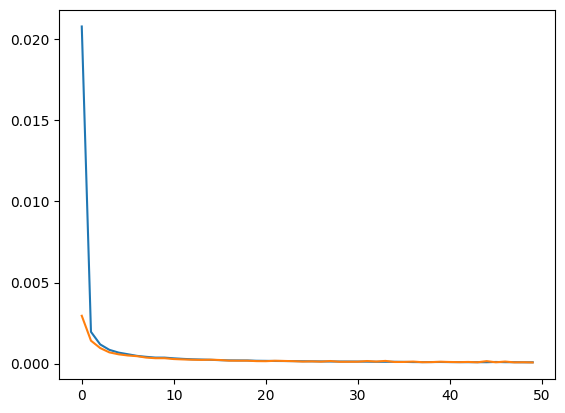

In [ ]:
%%time

###### STOOOOOOOOOOOOOOP ##########
###### STOOOOOOOOOOOOOOP ##########
###### STOOOOOOOOOOOOOOP ##########
###### STOOOOOOOOOOOOOOP ##########


####### THIS IS
#DONT RUN THIS BECAUSE THE WEIGHTS HAVE BEEN ALREADY COMPUTED. WE JUST NEED TO LOAD
#DONT RUN THIS BECAUSE THE WEIGHTS HAVE BEEN ALREADY COMPUTED. WE JUST NEED TO LOAD
#DONT RUN THIS BECAUSE THE WEIGHTS HAVE BEEN ALREADY COMPUTED. WE JUST NEED TO LOAD
#THE WEIGHTS

# ─────────────────────────────────────────────────────────────
# ENTRY POINT — replace with your real data
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # Convert the list of tensors into a single stacked tensor for the full dataset.
    # This ensures that subsequent operations like slicing and passing to the model/
    # train function receive a proper torch.Tensor, not a Python list.
    full_input_tensor = torch.stack(input_tensor, dim=0)
    full_output_tensor = torch.stack(output_tensor, dim=0)
    print(full_input_tensor.shape)
    print(full_output_tensor.shape)
    # ──────────────────── Quick architecture check ─────────────────────────
    # Always verify output shape before running the full training.
    model_check = Autoencoder(in_channels=3, out_channels=3)
    with torch.no_grad():
        # Now pass a slice of the stacked tensor
        test_out = model_check(full_input_tensor[:2])
    print(f"Output shape: {test_out.shape}")    # should be (2, in_channels, 128, 128)

    # ────────────────────────── Count parameters ───────────────────────────
    n_params = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")

    # ────────────────────────────── Train ────────────────────────────────
    trained_model,train_loss,val_loss = train(
  #      inputs        = full_input_tensor, # Pass the stacked tensor
  #      targets       = full_output_tensor, # Pass the stacked tensor
        num_epochs    = 50,
        batch_size    = 8,
        learning_rate = 1e-4,
        val_split     = 0.2,
    )

    # ─────────────────────── Save model weights ───────────────────────────
    # state_dict() stores only the learnable parameters, not the full
    # class, so it is the recommended way to persist a model.
    #torch.save(trained_model.state_dict(), "unet_weights.pth")
    torch.save(trained_model.state_dict(),f"{models_directory}/unet_weights.pth")
    print("Weights saved to unet_weights.pth")

    # ── Reload example ────────────────────────────────────────
    # model_new = UNet(in_channels=4, out_channels=2)
    # model_new.load_state_dict(torch.load("unet_weights.pth"))
    # model_new.eval()


import time
time.sleep(1)

In [ ]:
### Let us use a weight in the loss function so the training gives a prize when it is a defect

In [ ]:
class WeightedMSELoss(nn.Module):

    def __init__(self,
                 background_weight=1.0,
                 defect_weight=40.0):

        super().__init__()

        self.background_weight = background_weight
        self.defect_weight = defect_weight

    def forward(self, pred, target):

        # weight = torch.where(
        #     target > 0.05, ## this is the cutoff where a pixel contains are defect
        #     self.defect_weight,
        #     self.background_weight
        # )
        alpha = 40
        weight = 1.0 + alpha * target

        loss = weight * (pred - target)**2

        return loss.mean()

In [ ]:
%%time

# ─────────────────────────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────────────────────────

total_samples = len(stacked_input_tensor) # Use the length of the stacked tensor
train_size = int(0.8 * total_samples)
val_size = total_samples - train_size

def train(
#    inputs:       torch.Tensor,
#    targets:      torch.Tensor,
    num_epochs:   int   = 50,
    batch_size:   int   = 8,
    learning_rate:float = 1e-4,
    val_split:    float = 0.2,
):
    """
    Full training pipeline.

    inputs        : (N, 3, 128, 128) input tensors
    targets       : (N, 2, 128, 128) target tensors
    num_epochs    : how many full passes over the training set
    batch_size    : how many samples per gradient update
    learning_rate : step size for the Adam optimiser
    val_split     : fraction of data held out for validation
    """

    # ── Device setup ─────────────────────────────────────────
    # Automatically use a GPU if one is available; otherwise CPU.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")


    # ── Model, loss, optimiser ────────────────────────────────
    model = Autoencoder(in_channels=3, out_channels=3).to(device)

    # MSELoss computes the mean squared error between prediction and target.
    #For segmentation tasks you might swap this for CrossEntropyLoss
    #(with integer class maps) or BCEWithLogitsLoss.
    criterion = WeightedMSELoss(
    background_weight=1,
    defect_weight=40
      )

    # Adam is an adaptive gradient optimiser that works well out of the
    # box for most deep learning tasks.
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_losses = []
    val_losses = []

    # ── Training loop ─────────────────────────────────────────
    for epoch in range(1, num_epochs + 1):

        # ── Training phase ────────────────────────────────────
        model.train()   # enables dropout / BatchNorm training behaviour
        train_loss = 0.0

        for batch_inputs, batch_targets in train_loader:
            # Move data to the same device as the model.
            batch_inputs  = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)

            # Zero out gradients from the previous step. If you forget
            # this, gradients accumulate and your updates are wrong.
            optimizer.zero_grad()

            # Forward pass: compute the model's predictions.
            predictions = model(batch_inputs)

            # Compute the scalar loss between predictions and targets.
            loss = criterion(predictions, batch_targets)

            # Backward pass: compute gradients of the loss w.r.t. every
            # parameter via automatic differentiation (backprop).
            loss.backward()

            # Update parameters by taking one gradient descent step.
            optimizer.step()

            # Accumulate the loss (detach so no gradient history is kept).
            train_loss += loss.item() * batch_inputs.size(0)

        train_loss /= train_size  # average over samples
        train_losses.append(train_loss)



        # ── Validation phase ──────────────────────────────────


        model.eval()    # disables dropout / uses running stats for BN
        val_loss = 0.0

        with torch.no_grad():  # disable gradient computation to save memory
            for batch_inputs, batch_targets in val_loader:
                batch_inputs  = batch_inputs.to(device)
                batch_targets = batch_targets.to(device)

                predictions = model(batch_inputs)
                loss = criterion(predictions, batch_targets) # Validation loss
                # Loss between the predictions and the output (targets).
                val_loss += loss.item() * batch_inputs.size(0)

        val_loss /= val_size  # average over samples
        val_losses.append(val_loss)

        # Print progress every 10 epochs (and always at the last epoch).
        print(f"Epoch {epoch+1:3d}: "
              f"Train Loss = {train_loss:.4f}, "
              f"Val Loss = {val_loss:.4f}")

    print("Training complete.")

    import matplotlib.pyplot as plt
    plt.plot(train_losses)
    plt.plot(val_losses)

    return model, train_losses, val_losses



import time
time.sleep(1)

CPU times: user 549 µs, sys: 845 µs, total: 1.39 ms
Wall time: 1 s


torch.Size([1000, 3, 128, 128])
torch.Size([1000, 3, 128, 128])
Output shape: torch.Size([2, 3, 128, 128])
Trainable parameters: 31,037,763
Training on: cuda
Epoch   2: Train Loss = 0.1991, Val Loss = 0.0514
Epoch   3: Train Loss = 0.0256, Val Loss = 0.0146
Epoch   4: Train Loss = 0.0125, Val Loss = 0.0096
Epoch   5: Train Loss = 0.0084, Val Loss = 0.0069
Epoch   6: Train Loss = 0.0066, Val Loss = 0.0055
Epoch   7: Train Loss = 0.0053, Val Loss = 0.0048
Epoch   8: Train Loss = 0.0045, Val Loss = 0.0039
Epoch   9: Train Loss = 0.0041, Val Loss = 0.0034
Epoch  10: Train Loss = 0.0036, Val Loss = 0.0030
Epoch  11: Train Loss = 0.0032, Val Loss = 0.0027
Epoch  12: Train Loss = 0.0030, Val Loss = 0.0025
Epoch  13: Train Loss = 0.0029, Val Loss = 0.0024
Epoch  14: Train Loss = 0.0026, Val Loss = 0.0022
Epoch  15: Train Loss = 0.0023, Val Loss = 0.0020
Epoch  16: Train Loss = 0.0023, Val Loss = 0.0018
Epoch  17: Train Loss = 0.0020, Val Loss = 0.0017
Epoch  18: Train Loss = 0.0019, Val Loss =

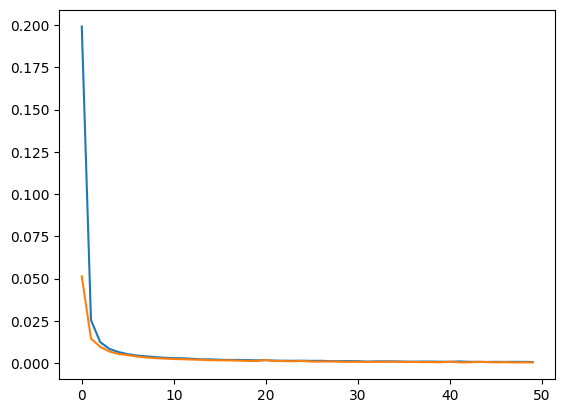

In [ ]:
%%time

###### STOOOOOOOOOOOOOOP ##########
###### STOOOOOOOOOOOOOOP ##########
###### STOOOOOOOOOOOOOOP ##########
###### STOOOOOOOOOOOOOOP ##########


####### THIS IS
#DONT RUN THIS BECAUSE THE WEIGHTS HAVE BEEN ALREADY COMPUTED. WE JUST NEED TO LOAD
#DONT RUN THIS BECAUSE THE WEIGHTS HAVE BEEN ALREADY COMPUTED. WE JUST NEED TO LOAD
#DONT RUN THIS BECAUSE THE WEIGHTS HAVE BEEN ALREADY COMPUTED. WE JUST NEED TO LOAD
#THE WEIGHTS

# ─────────────────────────────────────────────────────────────
# ENTRY POINT — replace with your real data
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # Convert the list of tensors into a single stacked tensor for the full dataset.
    # This ensures that subsequent operations like slicing and passing to the model/
    # train function receive a proper torch.Tensor, not a Python list.
    full_input_tensor = torch.stack(input_tensor, dim=0)
    full_output_tensor = torch.stack(output_tensor, dim=0)
    print(full_input_tensor.shape)
    print(full_output_tensor.shape)
    # ──────────────────── Quick architecture check ─────────────────────────
    # Always verify output shape before running the full training.
    model_check = Autoencoder(in_channels=3, out_channels=3)
    with torch.no_grad():
        # Now pass a slice of the stacked tensor
        test_out = model_check(full_input_tensor[:2])
    print(f"Output shape: {test_out.shape}")    # should be (2, in_channels, 128, 128)

    # ────────────────────────── Count parameters ───────────────────────────
    n_params = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")

    # ────────────────────────────── Train ────────────────────────────────
    trained_model,train_loss,val_loss = train(
  #      inputs        = full_input_tensor, # Pass the stacked tensor
  #      targets       = full_output_tensor, # Pass the stacked tensor
        num_epochs    = 50,
        batch_size    = 8,
        learning_rate = 1e-4,
        val_split     = 0.2,
    )

    # ─────────────────────── Save model weights ───────────────────────────
    # state_dict() stores only the learnable parameters, not the full
    # class, so it is the recommended way to persist a model.
    #torch.save(trained_model.state_dict(), "unet_weights.pth")
    torch.save(trained_model.state_dict(),f"{models_directory}/autoencoder(3)_weights.pth")
    print("Weights saved to unet_weights.pth")

    # ── Reload example ────────────────────────────────────────
    # model_new = UNet(in_channels=4, out_channels=2)
    # model_new.load_state_dict(torch.load("unet_weights.pth"))
    # model_new.eval()




import time
time.sleep(1)

In [ ]:
%%time

###### STOOOOOOOOOOOOOOP ##########
###### STOOOOOOOOOOOOOOP ##########
###### STOOOOOOOOOOOOOOP ##########
###### STOOOOOOOOOOOOOOP ##########


####### THIS IS
#DONT RUN THIS BECAUSE THE WEIGHTS HAVE BEEN ALREADY COMPUTED. WE JUST NEED TO LOAD
#DONT RUN THIS BECAUSE THE WEIGHTS HAVE BEEN ALREADY COMPUTED. WE JUST NEED TO LOAD
#DONT RUN THIS BECAUSE THE WEIGHTS HAVE BEEN ALREADY COMPUTED. WE JUST NEED TO LOAD
#THE WEIGHTS

# ─────────────────────────────────────────────────────────────
# ENTRY POINT — replace with your real data
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # Convert the list of tensors into a single stacked tensor for the full dataset.
    # This ensures that subsequent operations like slicing and passing to the model/
    # train function receive a proper torch.Tensor, not a Python list.
    full_input_tensor = torch.stack(input_tensor, dim=0)
    full_output_tensor = torch.stack(output_tensor, dim=0)
    print(full_input_tensor.shape)
    print(full_output_tensor.shape)
    # ──────────────────── Quick architecture check ─────────────────────────
    # Always verify output shape before running the full training.
    model_check = Autoencoder(in_channels=3, out_channels=3)
    with torch.no_grad():
        # Now pass a slice of the stacked tensor
        test_out = model_check(full_input_tensor[:2])
    print(f"Output shape: {test_out.shape}")    # should be (2, in_channels, 128, 128)

    # ────────────────────────── Count parameters ───────────────────────────
    n_params = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")

    # ────────────────────────────── Train ────────────────────────────────
    trained_model = train(
  #      inputs        = full_input_tensor, # Pass the stacked tensor
  #      targets       = full_output_tensor, # Pass the stacked tensor
        num_epochs    = 50,
        batch_size    = 8,
        learning_rate = 1e-4,
        val_split     = 0.2,
    )

    # ─────────────────────── Save model weights ───────────────────────────
    # state_dict() stores only the learnable parameters, not the full
    # class, so it is the recommended way to persist a model.
    #torch.save(trained_model.state_dict(), "unet_weights.pth")
    torch.save(trained_model.state_dict(),f"{models_directory}/autoencoder(2)_weights.pth")
    print("Weights saved to unet_weights.pth")

    # ── Reload example ────────────────────────────────────────
    # model_new = UNet(in_channels=4, out_channels=2)
    # model_new.load_state_dict(torch.load("unet_weights.pth"))
    # model_new.eval()




import time
time.sleep(1)

torch.Size([1000, 3, 128, 128])
torch.Size([1000, 3, 128, 128])
Output shape: torch.Size([2, 3, 128, 128])
Trainable parameters: 31,037,763
Training on: cuda
Epoch   2: Train Loss = 0.2330, Val Loss = 0.0439
Epoch   3: Train Loss = 0.0281, Val Loss = 0.0193
Epoch   4: Train Loss = 0.0163, Val Loss = 0.0134
Epoch   5: Train Loss = 0.0123, Val Loss = 0.0111
Epoch   6: Train Loss = 0.0101, Val Loss = 0.0086
Epoch   7: Train Loss = 0.0091, Val Loss = 0.0080
Epoch   8: Train Loss = 0.0076, Val Loss = 0.0069
Epoch   9: Train Loss = 0.0064, Val Loss = 0.0053
Epoch  10: Train Loss = 0.0057, Val Loss = 0.0052
Epoch  11: Train Loss = 0.0054, Val Loss = 0.0044
Epoch  12: Train Loss = 0.0050, Val Loss = 0.0041
Epoch  13: Train Loss = 0.0044, Val Loss = 0.0037
Epoch  14: Train Loss = 0.0042, Val Loss = 0.0034
Epoch  15: Train Loss = 0.0037, Val Loss = 0.0031
Epoch  16: Train Loss = 0.0036, Val Loss = 0.0032
Epoch  17: Train Loss = 0.0033, Val Loss = 0.0027
Epoch  18: Train Loss = 0.0035, Val Loss =